In [1]:
#imports essentiels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

#NLP imports
import nltk

from src.data_utils.data_loader import load_and_validate
from src.features.text_preprocessor import TextPreprocessor
from src.features.feature_engineering import add_text_features

#Téléchargement des ressources NLTK
nltk_downloads = ['stopwords', 'wordnet','punkt','averaged_perceptron_tagger']
for resource in nltk_downloads:
    try:
        nltk.data.find(f'tokenizers/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)
%matplotlib inline

In [2]:
df = load_and_validate("C:/Users/hajer/Documents/4-project_git/e_commerce_product_classification_with_Python/data/raw/flipkart_com-ecommerce_sample_1050.csv")

Données chargées avec succès : 1050 lignes, 15 colonnes
les colonnes:list[Index(['uniq_id', 'crawl_timestamp', 'product_url', 'product_name',
       'product_category_tree', 'pid', 'retail_price', 'discounted_price',
       'image', 'is_FK_Advantage_product', 'description', 'product_rating',
       'overall_rating', 'brand', 'product_specifications'],
      dtype='object')]


## Preparation des données textuelles
### Extraction des catégories et analyse

In [3]:
def extract_categories(df, category_col='product_category_tree'):
    """
    Extrait les catégories principales des produits
    """
    if category_col not in df.columns:
        raise ValueError(f"Colonne '{category_col}' non trouvée")

    # Séparation par '>>' et nettoyage
    categories = df[category_col].str.split('>>', expand=True)

    # Nettoyage de la première catégorie (principale)
    main_category = categories[0].str.replace(r'[^a-zA-Z]', '', regex=True)

    return main_category

def analyze_category_distribution(categories):
    """
    Analyse la distribution des catégories
    """
    category_counts = categories.value_counts()

    # Vérification de l'équilibrage des classes
    is_balanced = category_counts.std() / category_counts.mean() < 0.1

    print(f"Nombre de catégories : {len(category_counts)}")
    print(f"Classes équilibrées : {' Oui' if is_balanced else ' Non'}")

    return category_counts

def plot_category_distribution(category_counts):
    """
    Visualise la distribution des catégories
    """
    plt.figure(figsize=(10, 6))
    category_counts.plot(kind='bar', color='lightgreen')
    plt.title('Distribution des produits par catégorie', fontsize=16)
    plt.xlabel('Catégories')
    plt.ylabel('Nombre de produits')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Nombre de catégories : 7
Classes équilibrées :  Oui

Distribution des catégories :
target
HomeFurnishing           150
BabyCare                 150
Watches                  150
HomeDecorFestiveNeeds    150
KitchenDining            150
BeautyandPersonalCare    150
Computers                150
Name: count, dtype: int64


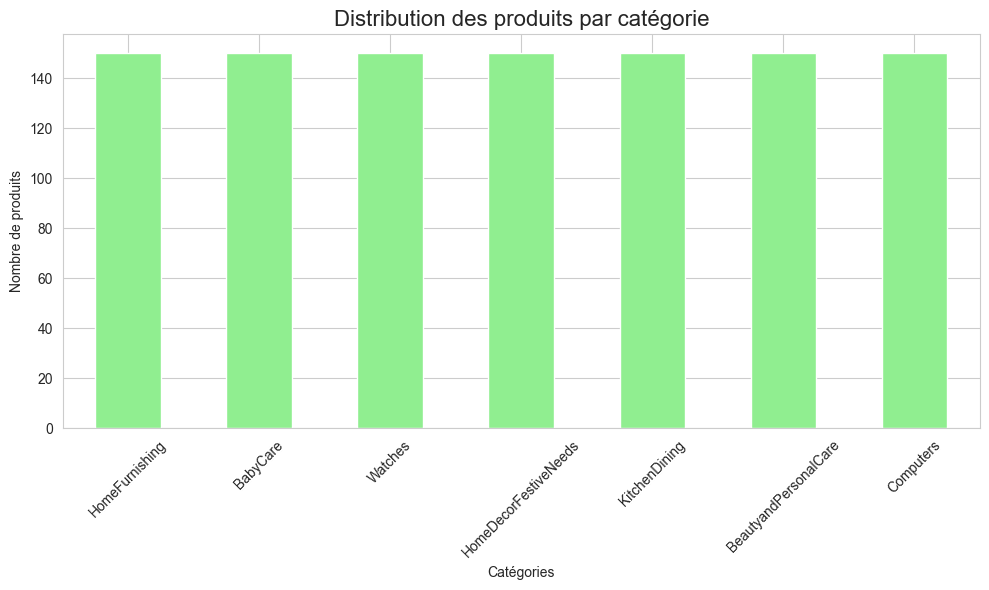

In [4]:
# 1. Extrayez les catégories principales
df['target'] = extract_categories(df)

# 2. Analysez la distribution
category_counts = analyze_category_distribution(df['target'])
print("\nDistribution des catégories :")
print(category_counts)

# 3. Visualisez la distribution
plot_category_distribution(category_counts)

In [5]:
# Cellule 4 : Business Intelligence - Analyse des prix
print("PRICING STRATEGY ANALYSIS")
print("=" * 40)

# Calcul du discount rate
df['discount_rate'] = ((df['retail_price'] - df['discounted_price']) / df['retail_price']) * 100

# Statistiques business
pricing_stats = {
    'Avg_Retail_Price': df['retail_price'].mean(),
    'Avg_Discounted_Price': df['discounted_price'].mean(),
    'Avg_Discount_Rate': df['discount_rate'].mean(),
    'Max_Discount': df['discount_rate'].max(),
    'Products_On_Sale': (df['discount_rate'] > 0).sum()
}

for key, value in pricing_stats.items():
    print(f"{key}: {value:.2f}")

PRICING STRATEGY ANALYSIS
Avg_Retail_Price: 2186.20
Avg_Discounted_Price: 1584.53
Avg_Discount_Rate: 32.62
Max_Discount: 91.95
Products_On_Sale: 858.00


In [6]:
def safe_numeric_conversion(series, column_name):
    """
    Conversion sécurisée vers numériques avec logging des erreurs
    """
    original_count = len(series)
    numerical_series = pd.to_numeric(series, errors='coerce')
    converted_count = numerical_series.notna().sum()
    print(f"{column_name}:{converted_count} / {original_count}'values converted successfully")
    return numerical_series

In [7]:
df['product_rating'] = safe_numeric_conversion(df['product_rating'], 'product_rating')
df['overall_rating'] = safe_numeric_conversion(df['overall_rating'], 'overall_rating')

product_rating:161 / 1050'values converted successfully
overall_rating:161 / 1050'values converted successfully


In [8]:
print("\n📊 CATEGORY PERFORMANCE ANALYSIS")
print("=" * 40)

category_performance = df.groupby('target').agg({
    'retail_price': 'mean',
    'discount_rate': 'mean',
    'product_rating': 'mean',
    'overall_rating': 'mean'
}).round(2).head(10)

print("\nCategory Performance Metrics:")
category_performance


📊 CATEGORY PERFORMANCE ANALYSIS

Category Performance Metrics:


,retail_price,discount_rate,product_rating,overall_rating
target,,,,
BabyCare,1291.95,29.99,3.08,3.08
BeautyandPersonalCare,1217.30,18.74,3.95,3.95
Computers,3647.52,43.02,3.76,3.76
HomeDecorFestiveNeeds,2796.89,34.25,4.31,4.31
HomeFurnishing,2108.87,37.93,3.83,3.83
KitchenDining,799.91,44.45,4.37,4.37
Watches,3434.97,19.95,3.84,3.84


## Préprocessing du texte (NLP)
### Fonction de nettoyage de texte

In [9]:
def analyze_text_by_category(df, text_col, target_col):
    """
    Analyse les caractéristiques textuelles par catégorie
    """
    text_stats = df.groupby(target_col)[['word_count', 'char_count', 'avg_word_length']].agg([
        'mean', 'std', 'min', 'max'
    ]).round(2)

    return text_stats

In [10]:
# 1. Initialisez le préprocesseur
preprocessor = TextPreprocessor()

# 2. Appliquez différentes méthodes de nettoyage
df['description_clean_basic'] = df['description'].apply(preprocessor.clean_text_basic)
df['description_clean_stem'] = df['description'].apply(lambda x: preprocessor.preprocess_text(x, method='stem'))
df['description_clean_lemma'] = df['description'].apply(lambda x: preprocessor.preprocess_text(x, method='lemma'))

# 3. Ajoutez des caractéristiques textuelles
df = add_text_features(df, 'description_clean_stem')

# 4. Analysez les caractéristiques par catégorie
print("Statistiques textuelles par catégorie :")
text_stats = analyze_text_by_category(df, 'description_clean_stem', 'target')
text_stats


Statistiques textuelles par catégorie :


word_count                 char_count                    \
                            mean    std min  max       mean     std min   max   
target                                                                          
BabyCare                   54.92  44.32   5  222     328.38  263.52  25  1305   
BeautyandPersonalCare      35.02  44.48   8  341     211.11  271.31  45  2103   
Computers                  56.08  70.69   4  347     334.07  429.23  25  2190   
HomeDecorFestiveNeeds      54.65  56.30   8  246     337.23  347.14  46  1576   
HomeFurnishing             38.17  42.77   5  257     233.68  263.58  23  1650   
KitchenDining              61.73  49.39   9  239     370.71  299.08  52  1446   
Watches                    29.09  19.07  14  162     172.65  119.85  81   998   

                      avg_word_length                    
                                 mean   std   min   max  
target                                                   
BabyCare                         6.00  0.41  5.00  7.57  
BeautyandPersonalCare            5.92  0.41  5.00  7.50  
Computers                        5.71  0.53  4.23  6.90  
HomeDecorFestiveNeeds            6.28  0.47  5.33  7.50  
HomeFurnishing                   6.22  0.58  4.60  8.00  
KitchenDining                    6.00  0.48  4.33  7.67  
Watches                          5.88  0.32  5.00  6.81

In [11]:
# 5. Comparez les différentes méthodes
sample_idx = 0
print(f"\nComparaison des méthodes de préprocessing (exemple {sample_idx}) :")
print(f"Original : {df.loc[sample_idx, 'description'][:100]}...")
print(f"Basic : {df.loc[sample_idx, 'description_clean_basic'][:100]}...")
print(f"Stemming : {df.loc[sample_idx, 'description_clean_stem'][:100]}...")
print(f"Lemmatisation : {df.loc[sample_idx, 'description_clean_lemma'][:100]}...")


Comparaison des méthodes de préprocessing (exemple 0) :
Original : Key Features of Elegance Polyester Multicolor Abstract Eyelet Door Curtain Floral Curtain,Elegance P...
Basic : key features of elegance polyester multicolor abstract eyelet door curtain floral curtain elegance p...
Stemming : key eleg polyest multicolor abstract eyelet door curtain floral curtain eleg polyest multicolor abst...
Lemmatisation : key elegance polyester multicolor abstract eyelet door curtain floral curtain elegance polyester mul...


## Fonctions d'analyse des mots

In [12]:
def get_word_frequency(texts, top_n=50):
    """
    Calcule la fréquence des mots dans un corpus
    """
    all_words = []
    for text in texts:
        if pd.notna(text):
            all_words.extend(text.split())

    word_freq = Counter(all_words)
    return dict(word_freq.most_common(top_n))

def plot_word_frequency(word_freq, title="Fréquence des mots", top_n=15):
    """
    Visualise la fréquence des mots
    """
    # Prendre seulement les top_n mots
    top_words = dict(list(word_freq.items())[:top_n])

    plt.figure(figsize=(12, 6))
    words = list(top_words.keys())
    frequencies = list(top_words.values())

    bars = plt.bar(words, frequencies, color='steelblue')
    plt.title(title, fontsize=16)
    plt.xlabel('Mots')
    plt.ylabel('Fréquence')
    plt.xticks(rotation=45, ha='right')

    # Ajouter les valeurs sur les barres
    for bar, freq in zip(bars, frequencies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(freq), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def analyze_words_by_category(df, text_col, target_col, top_n=20):
    """
    Analyse les mots les plus fréquents par catégorie
    """
    categories = df[target_col].unique()
    category_words = {}

    for category in categories:
        category_texts = df[df[target_col] == category][text_col]
        word_freq = get_word_frequency(category_texts, top_n)
        category_words[category] = word_freq

    return category_words

def plot_category_word_analysis(category_words, top_n=10):
    """
    Visualise les mots les plus fréquents par catégorie
    """
    n_categories = len(category_words)
    fig, axes = plt.subplots(n_categories, 1, figsize=(15, 4*n_categories))

    if n_categories == 1:
        axes = [axes]

    for idx, (category, word_freq) in enumerate(category_words.items()):
        # Prendre les top_n mots
        top_words = dict(list(word_freq.items())[:top_n])

        words = list(top_words.keys())
        frequencies = list(top_words.values())

        axes[idx].bar(words, frequencies, color=f'C{idx}')
        axes[idx].set_title(f'Top {top_n} mots - {category}', fontsize=14)
        axes[idx].set_xlabel('Mots')
        axes[idx].set_ylabel('Fréquence')
        axes[idx].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

def plot_text_length_distribution(df, target_col):
    """
    Visualise la distribution de la longueur des textes par catégorie
    """
    categories = df[target_col].unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))

    plt.figure(figsize=(12, 8))

    for i, category in enumerate(categories):
        data = df[df[target_col] == category]['word_count']
        plt.hist(data, bins=30, alpha=0.7, label=category, color=colors[i])

    plt.title('Distribution du nombre de mots par catégorie', fontsize=16)
    plt.xlabel('Nombre de mots')
    plt.ylabel('Fréquence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

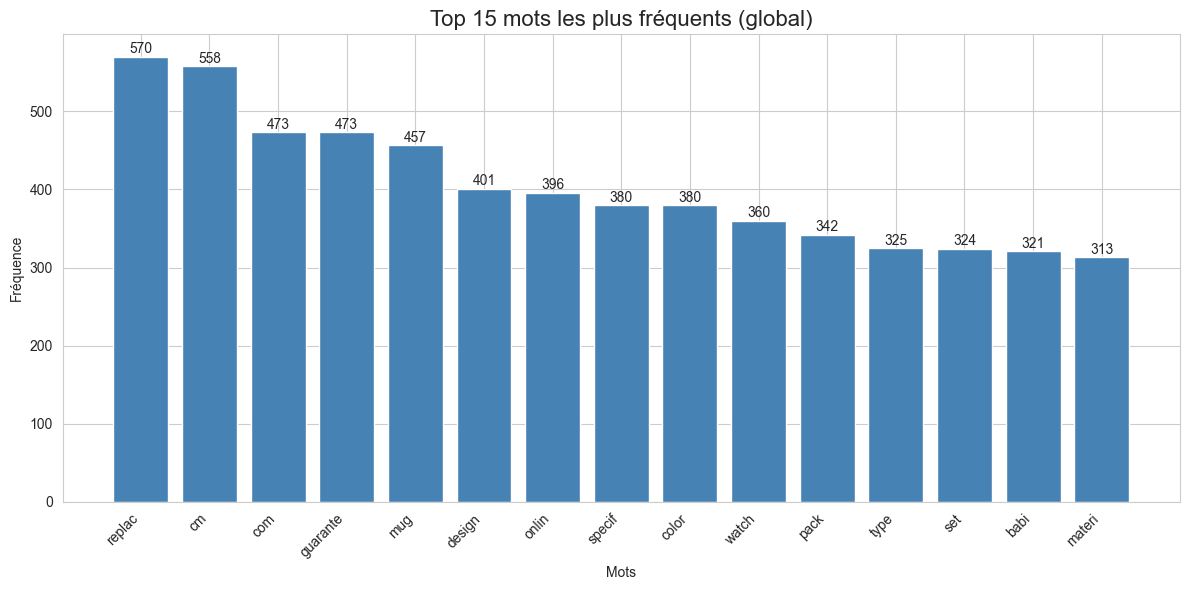

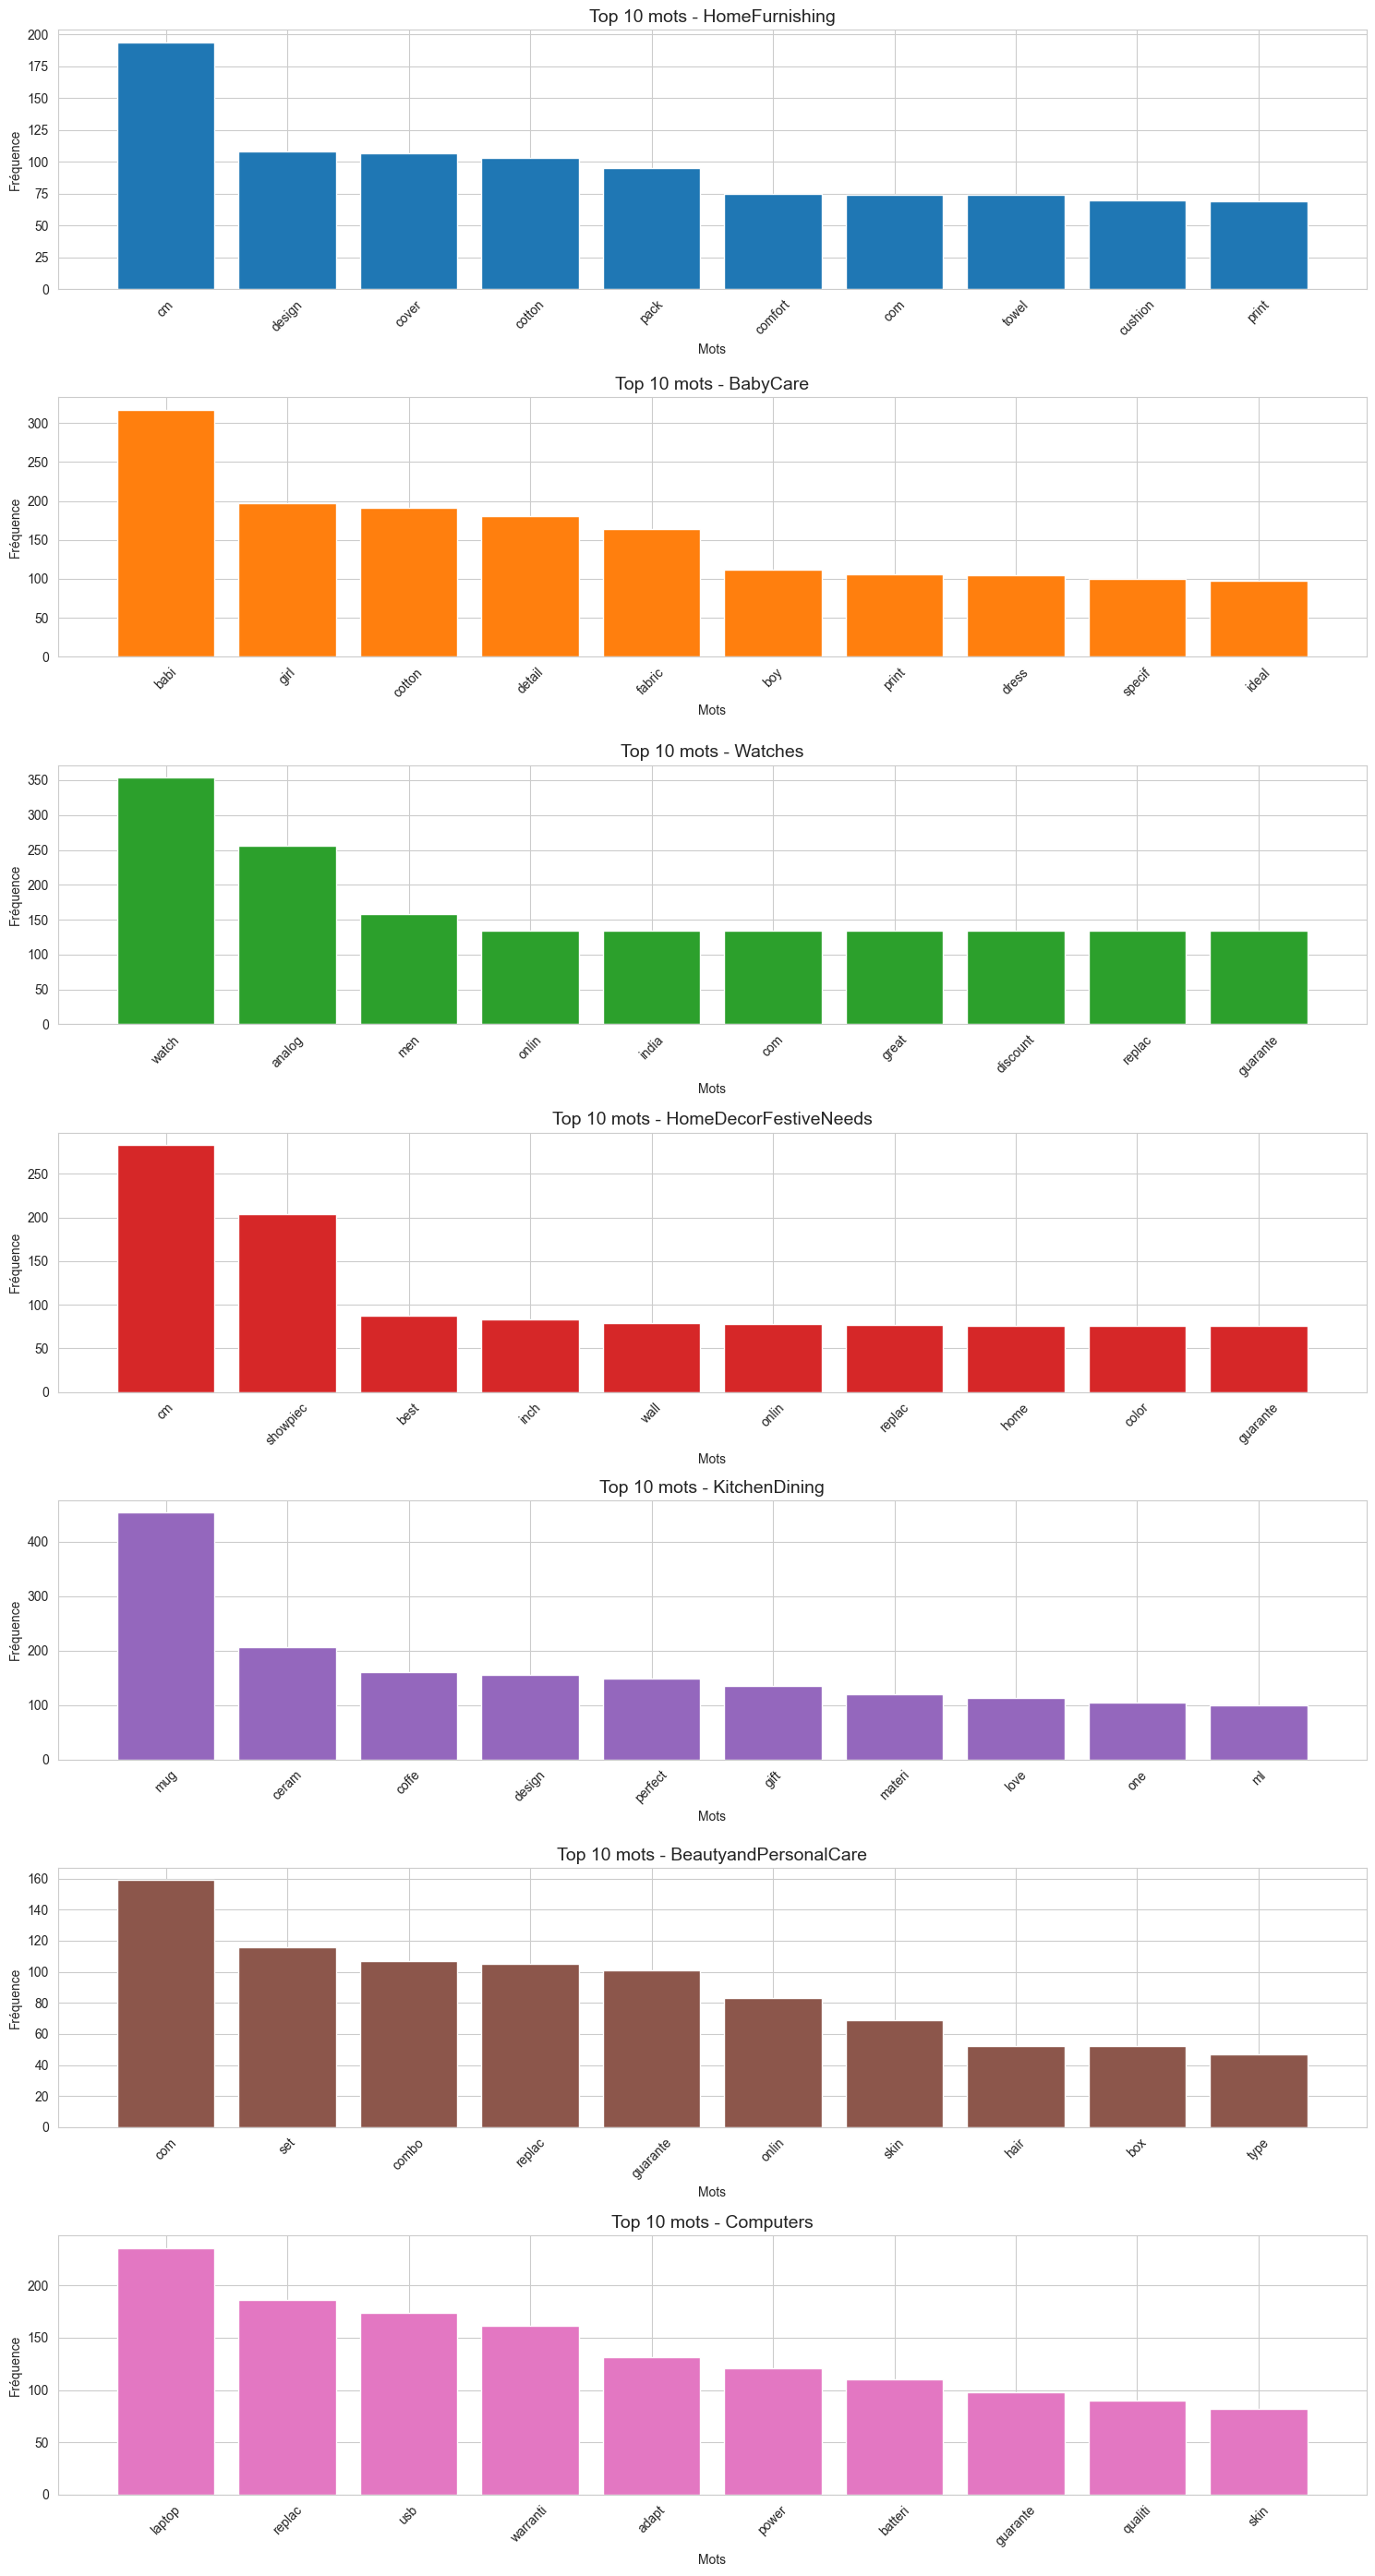

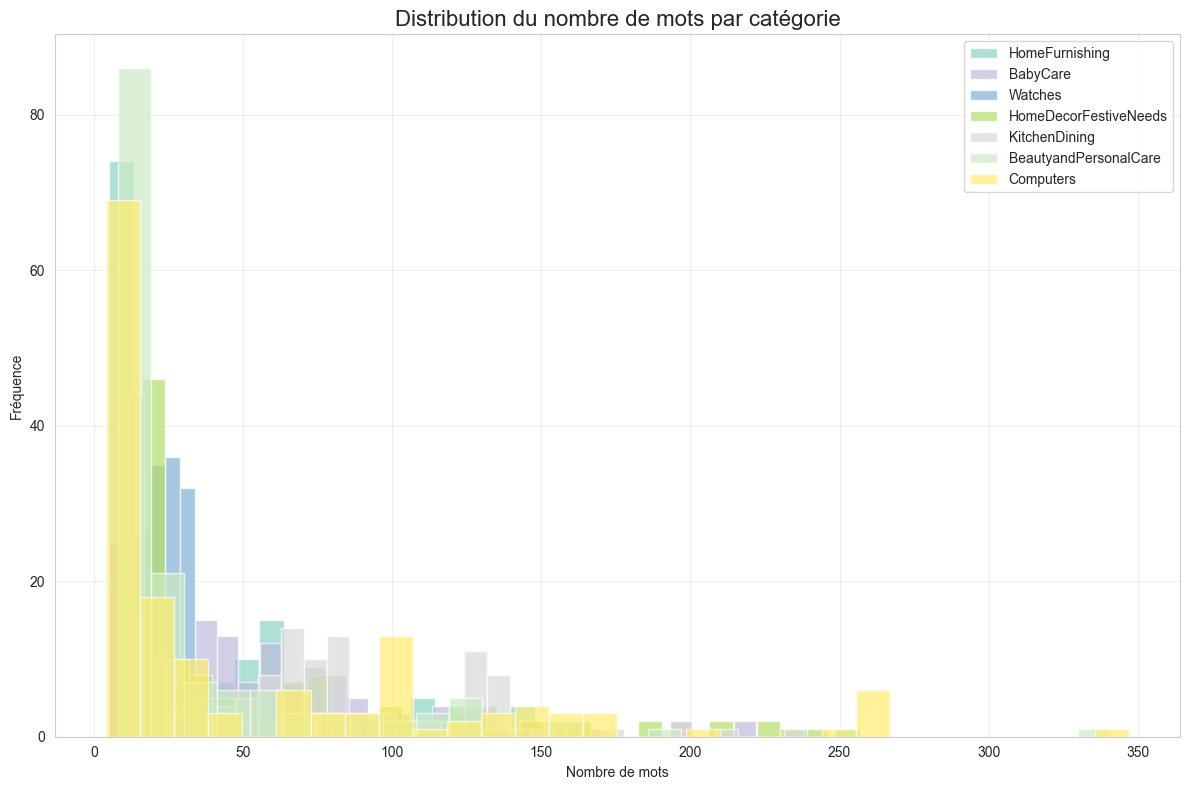


Comparaison Stemming vs Lemmatisation pour 'HomeFurnishing':


,Stemming,Freq_Stem,Lemmatisation,Freq_Lemma
0,cm,194,cm,195
1,design,108,cotton,103
2,cover,107,cover,101
3,cotton,103,pack,88
4,pack,95,design,79
5,comfort,75,com,74
6,com,74,towel,74
7,towel,74,cushion,70
8,cushion,70,color,66
9,print,69,inch,65


In [13]:
# 1. Analysez la fréquence globale des mots
global_word_freq = get_word_frequency(df['description_clean_stem'])
plot_word_frequency(global_word_freq, "Top 15 mots les plus fréquents (global)", 15)

# 2. Analysez les mots par catégorie
category_words = analyze_words_by_category(df, 'description_clean_stem', 'target', top_n=20)

# 3. Visualisez les mots par catégorie
plot_category_word_analysis(category_words, top_n=10)

# 4. Analysez la distribution de la longueur des textes
plot_text_length_distribution(df, 'target')

# 5. Comparez stemming vs lemmatisation pour une catégorie
sample_category = df['target'].iloc[0]
print(f"\nComparaison Stemming vs Lemmatisation pour '{sample_category}':")

stem_words = get_word_frequency(
    df[df['target'] == sample_category]['description_clean_stem'], top_n=10
)
lemma_words = get_word_frequency(
    df[df['target'] == sample_category]['description_clean_lemma'], top_n=10
)

comparison_df = pd.DataFrame({
    'Stemming': list(stem_words.keys()),
    'Freq_Stem': list(stem_words.values()),
    'Lemmatisation': list(lemma_words.keys()),
    'Freq_Lemma': list(lemma_words.values())
})
comparison_df

In [14]:
def compare_preprocessing_methods(df):
    """
    Compare les différentes méthodes de préprocessing
    """
    methods = {
        'Original': 'description',
        'Nettoyage basic': 'description_clean_basic',
        'Stemming': 'description_clean_stem',
        'Lemmatisation': 'description_clean_lemma'
    }

    comparison = {}

    for method_name, col_name in methods.items():
        if col_name in df.columns:
            # Calcul des métriques
            avg_words = df[col_name].str.split().str.len().mean()
            vocab_size = len(set(' '.join(df[col_name].fillna('')).split()))

            comparison[method_name] = {
                'Mots moyens par texte': round(avg_words, 2),
                'Taille du vocabulaire': vocab_size
            }

    return pd.DataFrame(comparison).T

def generate_recommendations(df, comparison_df):
    """
    Génère des recommandations basées sur l'analyse
    """
    recommendations = []

    # Analyse de l'équilibrage des classes
    class_balance = df['target'].value_counts()
    if class_balance.std() / class_balance.mean() < 0.1:
        recommendations.append("Classes bien équilibrées - pas besoin de rééchantillonnage")
    else:
        recommendations.append("Classes déséquilibrées - considérer le rééchantillonnage")

    # Analyse de la qualité des données
    missing_ratio = df['description'].isnull().sum() / len(df)
    if missing_ratio < 0.05:
        recommendations.append("Très peu de données manquantes dans les descriptions")
    else:
        recommendations.append(f"{missing_ratio:.2%} de descriptions manquantes - nettoyer avant modélisation")

    # Recommandations sur le préprocessing
    if 'Stemming' in comparison_df.index and 'Lemmatisation' in comparison_df.index:
        stem_vocab = comparison_df.loc['Stemming', 'Taille du vocabulaire']
        lemma_vocab = comparison_df.loc['Lemmatisation', 'Taille du vocabulaire']

        if stem_vocab < lemma_vocab * 0.9:
            recommendations.append("Le stemming réduit plus le vocabulaire - bon pour la performance")
        else:
            recommendations.append("La lemmatisation préserve mieux le sens - meilleure interprétabilité")

    return recommendations

# Exécution de l'analyse comparative
print("=== ANALYSE COMPARATIVE DES MÉTHODES DE PRÉPROCESSING ===")
comparison_df = compare_preprocessing_methods(df)
print(comparison_df)

print("\n=== RECOMMANDATIONS ===")
recommendations = generate_recommendations(df, comparison_df)
for rec in recommendations:
    print(rec)

# Sauvegarde des données nettoyées
filepath = Path('../data/processed/ecommerce_data_processed.csv')
#filepath.parent.mkdir(parents=False, exist_ok=True)
df.to_csv(filepath, index=False)
print(f"\n Données sauvegardées : {df.shape[0]} produits avec {df.shape[1]} variables")

=== ANALYSE COMPARATIVE DES MÉTHODES DE PRÉPROCESSING ===
                 Mots moyens par texte  Taille du vocabulaire
Original                         76.20                 9591.0
Nettoyage basic                  73.21                 5214.0
Stemming                         47.09                 4081.0
Lemmatisation                    47.09                 4662.0

=== RECOMMANDATIONS ===
Classes bien équilibrées - pas besoin de rééchantillonnage
Très peu de données manquantes dans les descriptions
Le stemming réduit plus le vocabulaire - bon pour la performance

 Données sauvegardées : 1050 produits avec 23 variables
